In [4]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.tree import plot_tree
from sklearn.preprocessing import LabelEncoder, StandardScaler

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split



# parte 1
se recolectaron los datos de kaggle, entre ellos los raitings de elo y los resultados de los partidos, entonces se unieron los datos del elo local y visitante, uniendolas con los resultados de los partidos co la funcion de merge_asof ya que las fechas de actualizacion de los rankings de elo no siempre seran las mismas en las que se jugo un partido.

In [ ]:
# 1. Rutas
DATA_DIR = "data"
partidos_path = os.path.join(DATA_DIR, "results.csv")
elos_path = os.path.join(DATA_DIR, "eloratings.csv")

print("Cargando los datasets...")
partidos = pd.read_csv(partidos_path)
elos = pd.read_csv(elos_path)

# 2. Convertir fechas y ORDENAR (Crucial para merge_asof)
partidos["date"] = pd.to_datetime(partidos["date"], format='mixed')
elos["date"] = pd.to_datetime(elos["date"], format='mixed')

partidos = partidos.sort_values("date")
elos = elos.sort_values("date")

# 3. UNIR ELO DEL LOCAL (Buscando el Elo más cercano en el pasado o igual)
print("Buscando el Elo histórico para los equipos locales...")
df_fusion = pd.merge_asof(
    partidos,
    elos,
    on="date",
    left_by="home_team",
    right_by="team",
    direction="backward"  # Busca el último Elo registrado hacia atrás
)
df_fusion = df_fusion.rename(columns={"rating": "elo_home"})
df_fusion = df_fusion.drop(columns=["team", "change"], errors='ignore')

# 4. UNIR ELO DEL VISITANTE
print("Buscando el Elo histórico para los equipos visitantes...")
df_final = pd.merge_asof(
    df_fusion,
    elos,
    on="date",
    left_by="away_team",
    right_by="team",
    direction="backward"
)
df_final = df_final.rename(columns={"rating": "elo_away"})
df_final = df_final.drop(columns=["team", "change"], errors='ignore')

# 5. CREAR VARIABLES
df_final["diferencia_elo"] = df_final["elo_home"] - df_final["elo_away"]

# 6. NUEVA EVALUACIÓN DE CALIDAD
print("\n--- NUEVO Conteo de filas vacías (Nulos) ---")
print(df_final[['elo_home', 'elo_away']].isna().sum())
print("Total de partidos originales:", len(df_final))



Cargando los datasets...
Buscando el Elo histórico para los equipos locales...
Buscando el Elo histórico para los equipos visitantes...

--- NUEVO Conteo de filas vacías (Nulos) ---
elo_home    12665
elo_away    12537
dtype: int64
Total de partidos originales: 49411


se filtraron y limpiaron los datos null del score home y away y se guardaron los datos en un nuevo csv llamado partidos_limpios_elo.csv


In [5]:
# 7. FILTRADO Y GUARDADO
df_limpio = df_final.dropna(subset=['elo_home', 'elo_away']).copy()

def determinar_resultado(row):
    if row['home_score'] > row['away_score']: return 'H'
    elif row['home_score'] < row['away_score']: return 'A'
    else: return 'D'

df_limpio['resultado'] = df_limpio.apply(determinar_resultado, axis=1)

print(f"\n¡Éxito! Partidos recuperados para el modelo: {len(df_limpio)}")

output_path = os.path.join(DATA_DIR, "partidos_limpios_elo.csv")
df_limpio.to_csv(output_path, index=False)
print(f"Dataset guardado en: {output_path}")


¡Éxito! Partidos recuperados para el modelo: 28811
Dataset guardado en: data\partidos_limpios_elo.csv


### analisis del tipo de torneos y la cantidad de estos jugados en el dataset


In [10]:
df = pd.read_csv(os.path.join(DATA_DIR, "partidos_limpios_elo.csv"))

# 1. Contar el número total de tipos de torneos
total_tipos = df['tournament'].nunique()
print(f"En total hay {total_tipos} tipos de torneos diferentes en el dataset.\n")

# Listar todos los torneos únicos y cuántas veces aparecen
print("--- Tipos de Torneos en el Dataset ---")
print(df['tournament'].value_counts().head(20))


En total hay 159 tipos de torneos diferentes en el dataset.

--- Tipos de Torneos en el Dataset ---
tournament
Friendly                                10776
FIFA World Cup qualification             5489
UEFA Euro qualification                  1913
African Cup of Nations qualification     1503
FIFA World Cup                            746
Copa América                              733
CECAFA Cup                                599
African Cup of Nations                    495
UEFA Nations League                       484
AFC Asian Cup qualification               451
UEFA Euro                                 320
AFF Championship                          277
Nordic Championship                       268
British Home Championship                 263
COSAFA Cup                                254
Merdeka Tournament                        226
CFU Caribbean Cup qualification           190
Gold Cup                                  185
AFC Asian Cup                             179
Southeast Asian

In [17]:
# Configurar rutas y cargar el dataset limpio
DATA_DIR = "data"
dataset_path = os.path.join(DATA_DIR, "partidos_limpios_elo.csv")

# Cargamos los datos
df = pd.read_csv(dataset_path)

# Configuración estética global para que tus gráficos se vean hermosos en el notebook
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 5]
%matplotlib inline 

print(f"¡Datos cargados con éxito! Total de partidos: {len(df)}")

¡Datos cargados con éxito! Total de partidos: 28811


# analisis eda

C:\Users\natal\AppData\Local\Temp\ipykernel_17560\4048841727.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Victoria Local', 'Empate', 'Victoria Visitante'], fontsize=11)


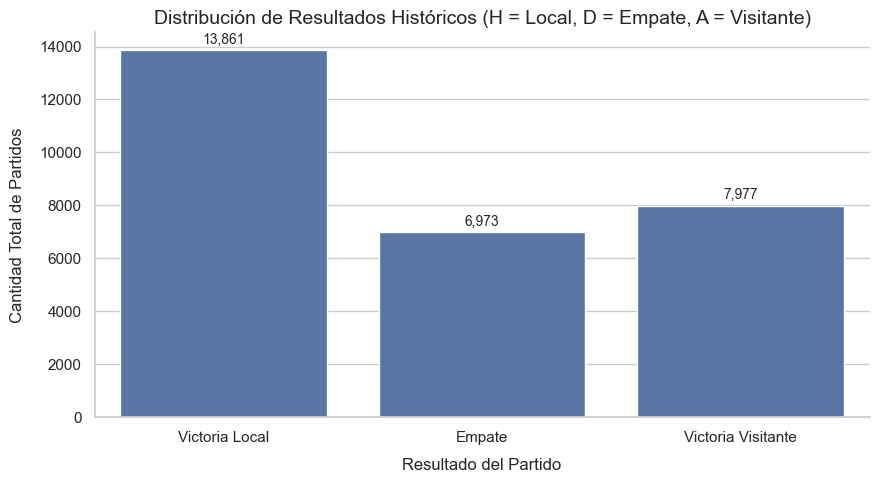

In [26]:
plt.figure(figsize=(10, 5))

# Creamos el gráfico de barras
ax = sns.countplot(data=df, x='resultado', order=['H', 'D', 'A'])

ax.set_xticklabels(['Victoria Local', 'Empate', 'Victoria Visitante'], fontsize=11)

# ¿Existe ventaja por jugar en casa? \nDistribución de Resultados Históricos en el Fútbol Mundial
plt.title('Distribución de Resultados Históricos (H = Local, D = Empate, A = Visitante)', fontsize=14)

plt.xlabel('Resultado del Partido', fontsize=12, labelpad=10)
plt.ylabel('Cantidad Total de Partidos', fontsize=12, labelpad=10)

# Añadimos el número exacto arriba de cada barra para que sea más fácil de leer
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 8), textcoords='offset points', fontsize=10)

sns.despine() # Quita los bordes innecesarios de la gráfica para que se vea más limpia
plt.show()

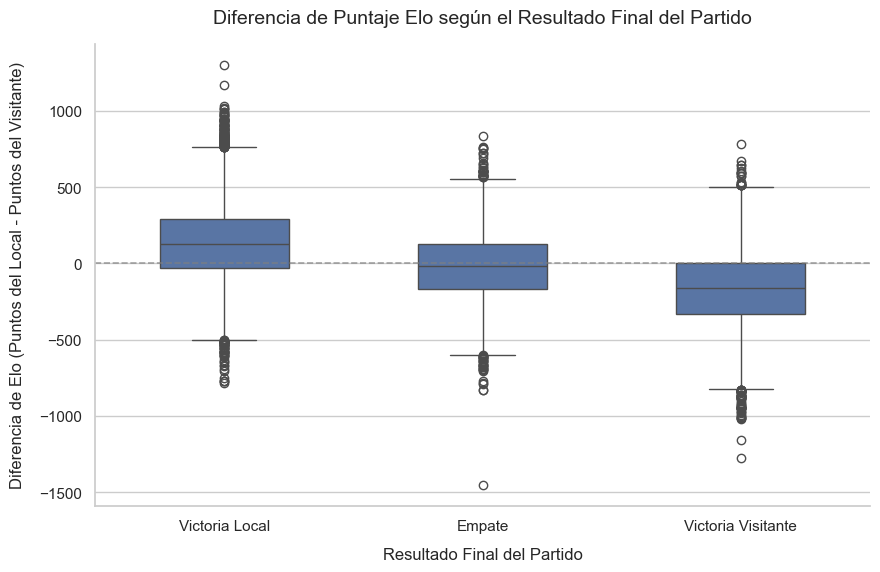

In [30]:
plt.figure(figsize=(10, 6))

# Creamos el diagrama de caja
ax = sns.boxplot(data=df, x='resultado', y='diferencia_elo', order=['H', 'D', 'A'], width=0.5)

ax.set_xticks(range(3))
# Cambiamos las etiquetas
ax.set_xticklabels(['Victoria Local', 'Empate', 'Victoria Visitante'], fontsize=11)

# Añadimos una línea de referencia en 0
plt.axhline(0, color='gray', linestyle='--', linewidth=1.2, alpha=0.7)

# T'¿El nivel de fuerza (Elo) determina el resultado? 
plt.title('Diferencia de Puntaje Elo según el Resultado Final del Partido', fontsize=14, pad=15)
plt.xlabel('Resultado Final del Partido', fontsize=12, labelpad=10)
plt.ylabel('Diferencia de Elo (Puntos del Local - Puntos del Visitante)', fontsize=12, labelpad=10)


sns.despine()
plt.show()

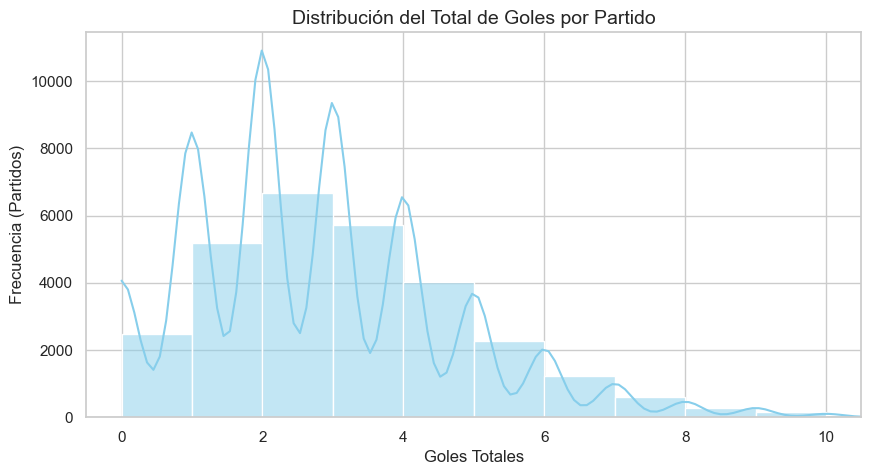

In [35]:
plt.figure()


# Sumamos los goles del local y del visitante para tener el total del partido
df['total_goles'] = df['home_score'] + df['away_score']

# Dibujamos un histograma para ver la frecuencia de la cantidad de goles
sns.histplot(data=df, x='total_goles', binwidth=1, kde=True, color='skyblue')

plt.title('Distribución del Total de Goles por Partido', fontsize=14)
plt.xlabel('Goles Totales', fontsize=12)
plt.ylabel('Frecuencia (Partidos)', fontsize=12)
plt.xlim(-0.5, 10.5) # Limitamos a 10 goles para que se vea ordenado

# Mostramos el gráfico en el notebook
plt.show()

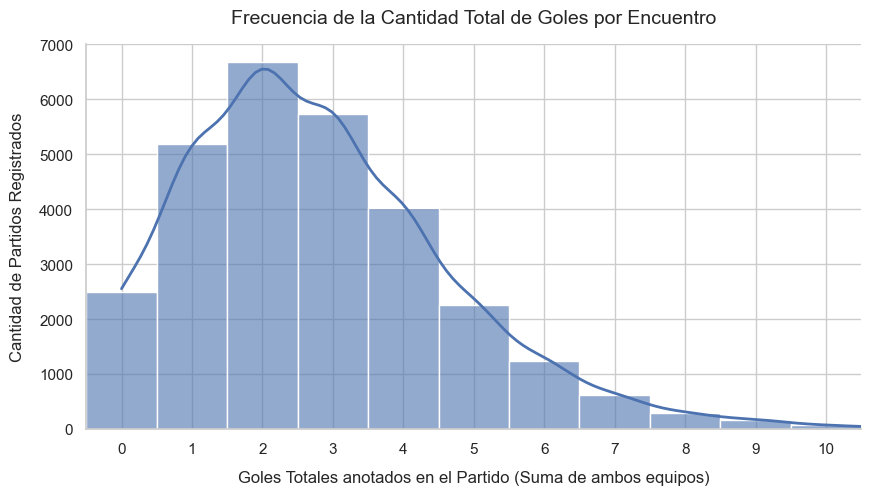

In [33]:
plt.figure(figsize=(10, 5))

# Creamos el histograma y suavizamos la línea KDE aumentando el 'bw_adjust'
ax = sns.histplot(
    data=df, 
    x='total_goles', 
    binwidth=1, 
    discrete=True, 
    kde=True, 
    alpha=0.6,
    line_kws={'linewidth': 2},
    kde_kws={'bw_adjust': 2} # ¡Esto es lo que suaviza la curva tipo montaña rusa!
)

# Configuramos el eje X para que muestre exactamente los números de goles del 0 al 10
plt.xticks(range(0, 11))
plt.xlim(-0.5, 10.5)

# Títulos profesionales
plt.title('Frecuencia de la Cantidad Total de Goles por Encuentro', fontsize=14,  pad=15)
plt.xlabel('Goles Totales anotados en el Partido (Suma de ambos equipos)', fontsize=12, labelpad=10)
plt.ylabel('Cantidad de Partidos Registrados', fontsize=12, labelpad=10)

sns.despine()
plt.show()

# 5. ingenieria de variables (ojo)
se crearon variables para el analisis, como ser los puntos para el local, y para el visitante, la diferencia de coles por partido, y el peso del tipo de torneo, 3 si es del mundial, 1 si es un amistoso, 5 para los demas torneos
## medidas a mejorar/ajustar/corregir:

    ## agregar los pesos de mas juegos, que vayan del 1 al 4, evaluar los tipos de partidos
    ## ver lo de los valores espejo, para las futuras predicciones
    ## algo mas debe haber revisar mas 




In [3]:

# 1. Cargar nuestro dataset limpio original
DATA_DIR = "data"
dataset_path = os.path.join(DATA_DIR, "partidos_limpios_elo.csv")
df_features = pd.read_csv(dataset_path)

print("Calculando variables de rendimiento directas...")

# --- 1. PUNTOS OBTENIDOS EN EL PARTIDO (P_t) ---
# Puntos para el Local
df_features['puntos_home'] = np.select(
    [df_features['home_score'] > df_features['away_score'], df_features['home_score'] == df_features['away_score']],
    [3, 1], default=0
)
# Puntos para el Visitante
df_features['puntos_away'] = np.select(
    [df_features['away_score'] > df_features['home_score'], df_features['home_score'] == df_features['away_score']],
    [3, 1], default=0
)

# --- 2. DIFERENCIA DE GOLES EN EL PARTIDO (DG_t) ---
df_features['dif_goles_home'] = df_features['home_score'] - df_features['away_score']
df_features['dif_goles_away'] = df_features['away_score'] - df_features['home_score']

# --- 3. PESO DEL TORNEO (Escala: 1, 3, 5) ---
# 3 si es del mundial, 1 si es amistoso, 5 para otros torneos (eliminatorias, copas, etc.)
def asignar_peso_estricto(torneo):
    torneo = str(torneo).lower()
    if 'world cup' in torneo and 'qual' not in torneo:
        return 3  # Mundial
    elif 'friendly' in torneo or 'amistoso' in torneo:
        return 1  # Amistoso
    else:
        return 5  # Otros torneos

df_features['peso_torneo'] = df_features['tournament'].apply(asignar_peso_estricto)

# 4. Guardar el progreso
df_features.to_csv(os.path.join(DATA_DIR, "partidos_con_features_basicas.csv"), index=False)

print("¡Variables de efectividad y peso de torneo creadas con éxito!")
print(df_features[['home_team', 'away_team', 'puntos_home', 'dif_goles_home', 'peso_torneo']].head())

Calculando variables de rendimiento directas...
¡Variables de efectividad y peso de torneo creadas con éxito!
  home_team away_team  puntos_home  dif_goles_home  peso_torneo
0  Scotland   England            1             0.0            1
1   England  Scotland            3             2.0            1
2  Scotland   England            3             1.0            1
3   England  Scotland            1             0.0            1
4  Scotland   England            3             3.0            1


# entrenar models de baseline

se hicieron 2 regresiones, la log y el arbol de decision, ambas con un accuracy similar (55%), pero la precision al momento los empates varia, en el la log es de 0, mientras que en el el arbol de decisiones sube a 0.40, que, aunque en ambos moedlos prefiere elegir una victoria local en vez de un empate, tiene sentido al tratarse de futbol

In [4]:
# 1. SOLUCIÓN AL DATA LEAKAGE: Usamos solo variables conocidas ANTES del partido
columnas_modelo = ['elo_home', 'elo_away', 'diferencia_elo', 'peso_torneo']

# Filtramos filas vacías
df_entrenamiento = df_features.dropna(subset=columnas_modelo).copy()

# 2. Seleccionar las variables legítimas
X = df_entrenamiento[columnas_modelo]
y = df_entrenamiento['resultado']

# 3. Dividir en datos de entrenamiento (80%) y evaluación (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entrenando modelo BASELINE con {len(X_train)} partidos...")

# 4. Entrenar la IA
modelo_base = LogisticRegression(max_iter=1000)
modelo_base.fit(X_train, y_train)

# 5. Evaluar el rendimiento real
y_pred = modelo_base.predict(X_test)
precision = accuracy_score(y_test, y_pred)

print(f"\n--- ¡PRUEBA REALISTA COMPLETADA! ---")
print(f"Precisión General Real (Accuracy): {precision:.2%}\n")
print(classification_report(y_test, y_pred, target_names=['Victoria Visitante (A)', 'Empate (D)', 'Victoria Local (H)']))

Entrenando modelo BASELINE con 23048 partidos...

--- ¡PRUEBA REALISTA COMPLETADA! ---
Precisión General Real (Accuracy): 55.54%

                        precision    recall  f1-score   support

Victoria Visitante (A)       0.49      0.55      0.52      1573
            Empate (D)       0.00      0.00      0.00      1433
    Victoria Local (H)       0.58      0.85      0.69      2757

              accuracy                           0.56      5763
             macro avg       0.36      0.47      0.40      5763
          weighted avg       0.41      0.56      0.47      5763



c:\Users\natal\Desktop\HomeWorks\Mundial\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\natal\Desktop\HomeWorks\Mundial\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\natal\Desktop\HomeWorks\Mundial\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri

In [5]:

# 1. Usamos las mismas variables conocidas antes del partido
columnas_modelo = ['elo_home', 'elo_away', 'diferencia_elo', 'peso_torneo']

X = df_entrenamiento[columnas_modelo]
y = df_entrenamiento['resultado']

# Usamos la misma división de datos anterior (gracias al random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Entrenando Árbol de Decisión con {len(X_train)} partidos...")

# 2. Crear y entrenar el Árbol de Decisión
modelo_arbol = DecisionTreeClassifier(max_depth=5, random_state=42)
modelo_arbol.fit(X_train, y_train)

# 3. Evaluar el rendimiento
y_pred_arbol = modelo_arbol.predict(X_test)
precision_arbol = accuracy_score(y_test, y_pred_arbol)

print(f"\n--- ¡PRUEBA CON ÁRBOL COMPLETADA! ---")
print(f"Precisión General del Árbol (Accuracy): {precision_arbol:.2%}\n")
print(classification_report(y_test, y_pred_arbol, target_names=['Victoria Visitante (A)', 'Empate (D)', 'Victoria Local (H)']))

Entrenando Árbol de Decisión con 23048 partidos...

--- ¡PRUEBA CON ÁRBOL COMPLETADA! ---
Precisión General del Árbol (Accuracy): 55.42%

                        precision    recall  f1-score   support

Victoria Visitante (A)       0.52      0.48      0.50      1573
            Empate (D)       0.40      0.00      0.00      1433
    Victoria Local (H)       0.56      0.89      0.69      2757

              accuracy                           0.55      5763
             macro avg       0.50      0.45      0.40      5763
          weighted avg       0.51      0.55      0.47      5763



## secuencia gru
### moldear los datos para el gru
se genero un X_tensor con la forma de (partidos, 5,4)
en el primer eje tenemos las isntancias/partidos (cuantos partidos historicos tenemos registrados que tengan un pasado del al menos 5 juegos)
en el eje 1 la secuencia temporal, es decir 5 pasos, representa el pasado, fijandolo en 5 le decimos al modelo gru que mire exactamente 5 partidos hacia atras en la historis de ese equipo
eje 2 son las caracteristicas/ features, que son 4, las 4 pistas que elegimos para que la red analice cada uno de los 5 partidos pasados: elo propio, elo rival, resultado (3 gano, 1 empate, 0 perder) y la diferencia de goles
        
        # Aca se aplico el espejo, ojo revisar

In [5]:
# 1. Cargar el dataset limpio original
DATA_DIR = "data"
df = pd.read_csv(os.path.join(DATA_DIR, "partidos_limpios_elo.csv"))

# Asegurar orden cronológico
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print("Estructurando perspectivas de equipos para la racha...")

# 2. El Espejo: Separar filas por equipo para no perder ningún partido pasado
df_local = df.copy()
df_local['equipo'] = df_local['home_team']
df_local['rival'] = df_local['away_team']
df_local['elo_propio'] = df_local['elo_home']
df_local['elo_rival'] = df_local['elo_away']
df_local['goles_favor'] = df_local['home_score']
df_local['goles_contra'] = df_local['away_score']

df_vis = df.copy()
df_vis['equipo'] = df_vis['away_team']
df_vis['rival'] = df_vis['home_team']
df_vis['elo_propio'] = df_vis['elo_away']
df_vis['elo_rival'] = df_vis['elo_home']
df_vis['goles_favor'] = df_vis['away_score']
df_vis['goles_contra'] = df_vis['home_score']

# Juntamos todo en un historial unificado por equipo
df_historial = pd.concat([df_local, df_vis]).sort_values(['equipo', 'date']).reset_index(drop=True)

# Llenamos nulos residuales en goles históricos con la moda (0 o 1) para evitar fallas
df_historial['goles_favor'] = df_historial['goles_favor'].fillna(1).astype(int)
df_historial['goles_contra'] = df_historial['goles_contra'].fillna(1).astype(int)

# 3. Ingeniería de Variables para la GRU (¿Qué queremos que recuerde de la racha?)
df_historial['resultado_puntos'] = np.select(
    [df_historial['goles_favor'] > df_historial['goles_contra'], df_historial['goles_favor'] == df_historial['goles_contra']],
    [3, 1], default=0
)
df_historial['dif_goles'] = df_historial['goles_favor'] - df_historial['goles_contra']

# Normalizamos el Elo para que la red neuronal aprenda más rápido
scaler = StandardScaler()
df_historial[['elo_propio', 'elo_rival', 'dif_goles']] = scaler.fit_transform(
    df_historial[['elo_propio', 'elo_rival', 'dif_goles']]
)

# 4. Creación de Ventanas Temporales (Últimos 5 partidos)
X_secuencias = []
y_objetivos = []

# Guardamos las variables que formarán la "memoria" de la racha
features_racha = ['elo_propio', 'elo_rival', 'resultado_puntos', 'dif_goles']

# Agrupamos por país y extraemos bloques de 5 partidos
for equipo, grupo in df_historial.groupby('equipo'):
    valores = grupo[features_racha].values
    resultados = grupo['resultado'].values # H, D, A original del partido actual
    
    # Necesitamos al menos 5 partidos en el pasado para poder armar la racha
    for i in range(5, len(grupo)):
        # Guardamos los 5 partidos anteriores (del i-5 al i-1)
        ventana = valores[i-5:i]
        X_secuencias.append(ventana)
        y_objetivos.append(resultados[i])

# Transformamos a tensores numéricos listos para Inteligencia Artificial
X_tensor = np.array(X_secuencias)

# Codificamos las etiquetas H, D, A a números 0, 1, 2
le = LabelEncoder()
y_tensor = le.fit_transform(y_objetivos)

print("\n--- ¡ESTRUCTURA GRU PREPARADA SIN ERRORES! ---")
print(f"Forma del tensor X (Partidos, Tamaño Racha, Características): {X_tensor.shape}")
print(f"Forma del tensor y (Resultados mapeados): {y_tensor.shape}")
print(f"Clases asignadas por el encoder: {le.classes_} -> mapeados a [0, 1, 2]")

Estructurando perspectivas de equipos para la racha...

--- ¡ESTRUCTURA GRU PREPARADA SIN ERRORES! ---
Forma del tensor X (Partidos, Tamaño Racha, Características): (56755, 5, 4)
Forma del tensor y (Resultados mapeados): (56755,)
Clases asignadas por el encoder: ['A' 'D' 'H'] -> mapeados a [0, 1, 2]


dividir y preparar los datos sen PyTorch, convirtiendo los arreglos de Numpy en tensores nativos de pytorch, division 80 y 20

In [6]:
# 1. Pasar de NumPy a Tensores de PyTorch (con los tipos de datos correctos)
X_torch = torch.tensor(X_tensor, dtype=torch.float32)
y_torch = torch.tensor(y_tensor, dtype=torch.long)

# 2. Dividir en Entrenamiento (80%) y Prueba (20%) manteniendo el orden aleatorio consistente
X_train, X_test, y_train, y_test = train_test_split(X_torch, y_torch, test_size=0.2, random_state=42)

# 3. Crear DataLoaders (herramienta de PyTorch que le pasa los datos a la IA en paquetitos o 'batches')
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# Procesaremos los partidos de 64 en 64 para no saturar la memoria
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Datos listos para la Red Neuronal.")
print(f"Paquetes de entrenamiento: {len(train_loader)} | Paquetes de prueba: {len(test_loader)}")

Datos listos para la Red Neuronal.
Paquetes de entrenamiento: 710 | Paquetes de prueba: 178


# Entrenamiento de la red neuronal
usamos adam que es un algoritmoque decide como y cuando deben cambiar los pesos de la GRU para evitar repetir errores

In [7]:

class PredictorMundialGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PredictorMundialGRU, self).__init__()
        self.hidden_size = hidden_size
        
        # ¡ARREGLADO AQUÍ: cambiamos 'batch_size_first' por 'batch_first'!
        self.gru = nn.GRU(input_size, hidden_size, batch_first=True)
        
        # Capa de salida totalmente conectada (Dense layer)
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        # x tiene forma: (batch_size, 5, 4)
        
        # Pasamos la secuencia por la GRU
        out, _ = self.gru(x) # out contiene la salida de los 5 pasos de tiempo
        
        # Tomamos solo el último paso de tiempo (el partido de racha más reciente)
        ultimo_paso = out[:, -1, :] # forma: (batch_size, hidden_size)
        
        # Pasamos el resultado por la capa final para obtener los 3 puntajes de predicción
        prediccion = self.fc(ultimo_paso)
        return prediccion

# Instanciamos el modelo: 4 entradas (features), 64 neuronas ocultas, 3 salidas (A, D, H)
modelo_gru = PredictorMundialGRU(input_size=4, hidden_size=64, output_size=3)
print("--- ¡ARQUITECTURA CORREGIDA CON ÉXITO! ---")
print(modelo_gru)

--- ¡ARQUITECTURA CORREGIDA CON ÉXITO! ---
PredictorMundialGRU(
  (gru): GRU(4, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=3, bias=True)
)


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(modelo_gru.parameters(), lr=0.001)

epochs = 5 # Lo bajamos a 5 para probar rápido este microscopio
print("Iniciando entrenamiento con monitoreo por Batch...\n")

for epoch in range(epochs):
    modelo_gru.train()
    loss_acumulada = 0.0
    
    # Agregamos 'enumerate' para saber en qué número de batch vamos
    for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
        optimizer.zero_grad()
        outputs = modelo_gru(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        
        loss_acumulada += loss.item()
        
        # --- NUEVO: Monitoreo cada 200 batches ---
        if batch_idx % 200 == 0:
            print(f"Época [{epoch+1}/{epochs}] | Paquete [{batch_idx}/{len(train_loader)}] | Loss del Batch: {loss.item():.4f}")
            
    print(f"--> FINAL ÉPOCA [{epoch+1}/{epochs}] - Pérdida Promedio Total: {loss_acumulada/len(train_loader):.4f}\n")

print("¡Monitoreo completado!")

Iniciando entrenamiento con monitoreo por Batch...

Época [1/5] | Paquete [0/710] | Loss del Batch: 1.0482
Época [1/5] | Paquete [200/710] | Loss del Batch: 1.0450
Época [1/5] | Paquete [400/710] | Loss del Batch: 1.1015
Época [1/5] | Paquete [600/710] | Loss del Batch: 1.0660
--> FINAL ÉPOCA [1/5] - Pérdida Promedio Total: 1.0460

Época [2/5] | Paquete [0/710] | Loss del Batch: 1.0798
Época [2/5] | Paquete [200/710] | Loss del Batch: 1.1368
Época [2/5] | Paquete [400/710] | Loss del Batch: 1.0328
Época [2/5] | Paquete [600/710] | Loss del Batch: 1.0820
--> FINAL ÉPOCA [2/5] - Pérdida Promedio Total: 1.0456

Época [3/5] | Paquete [0/710] | Loss del Batch: 1.1272
Época [3/5] | Paquete [200/710] | Loss del Batch: 1.0690
Época [3/5] | Paquete [400/710] | Loss del Batch: 0.9991
Época [3/5] | Paquete [600/710] | Loss del Batch: 1.0780
--> FINAL ÉPOCA [3/5] - Pérdida Promedio Total: 1.0452

Época [4/5] | Paquete [0/710] | Loss del Batch: 1.0355
Época [4/5] | Paquete [200/710] | Loss del Batc

In [9]:
import torch
from sklearn.metrics import accuracy_score, classification_report

# 1. Poner la red neuronal en modo EVALUACIÓN (apaga el aprendizaje)
modelo_gru.eval()

todas_predicciones = []
todos_resultados_reales = []

# Desactivamos el cálculo de gradientes para que vaya súper rápido y no consuma RAM
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = modelo_gru(X_batch)
        
        # outputs contiene las probabilidades/scores para [A, D, H]
        # Con torch.max elegimos el índice del puntaje más alto (0, 1 o 2)
        _, predicciones = torch.max(outputs, 1)
        
        # Guardamos las predicciones y las realidades pasándolas a NumPy
        todas_predicciones.extend(predicciones.numpy())
        todos_resultados_reales.extend(y_batch.numpy())

# 2. Calcular las métricas finales de la GRU
precision_gru = accuracy_score(todos_resultados_reales, todas_predicciones)

print(f"--- EVALUACIÓN FINAL DE LA GRU ---")
print(f"Precisión General (Accuracy): {precision_gru:.2%}\n")
print(classification_report(todos_resultados_reales, todas_predicciones, target_names=['Victoria Visitante (A)', 'Empate (D)', 'Victoria Local (H)']))

--- EVALUACIÓN FINAL DE LA GRU ---
Precisión General (Accuracy): 48.12%

                        precision    recall  f1-score   support

Victoria Visitante (A)       0.41      0.01      0.01      3152
            Empate (D)       0.00      0.00      0.00      2738
    Victoria Local (H)       0.48      1.00      0.65      5461

              accuracy                           0.48     11351
             macro avg       0.30      0.33      0.22     11351
          weighted avg       0.35      0.48      0.32     11351



c:\Users\natal\Desktop\HomeWorks\Mundial\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\natal\Desktop\HomeWorks\Mundial\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\natal\Desktop\HomeWorks\Mundial\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metri